In [78]:
# -*- coding: utf-8 -*-
"""
Created on Fri Dec  3 14:55:42 2021

@author: ladretp
"""

# Standard library imports
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm

import pickle
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, balanced_accuracy_score


from sklearn.metrics import balanced_accuracy_score,classification_report
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import utils_ClassIm as utils

# import pour la partie CNN


from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

from tensorflow.keras import backend as K 

#import transfer

from tensorflow.keras.applications.vgg16 import VGG16

from tensorflow.keras.models import Model
#########################################################################""




plt.close('all')


In [79]:

# Main

# Partie 1.1 Recuperation de la base de données type DataFrame
database = pd.read_csv('./database.csv')
# Paramètres

# Etude sur catégorie 2 classes == 0 ou 8 classes == 1
ColLabels = 1

#remettre les données dans l'ordre des images

base_ordre=database.sort_values(by=['Numero'])

# Etude sur catégorie 2 classes ColLabels=0 ou 8 classes ColLabels= 1 uniquement
ColLabels = 1

########### visualisation des données ###########

T = database.describe()  #on représente les statistiques descriptives
print(T)


            Numero  GaborFeature0  GaborFeature1  GaborFeature2  \
count  2688.000000   2.688000e+03   2.688000e+03   2.688000e+03   
mean   1343.500000   1.850372e-17   7.004979e-17   1.321694e-17   
std     776.103086   1.000186e+00   1.000186e+00   1.000186e+00   
min       0.000000  -5.507909e-01  -5.507426e-01  -6.685841e-01   
25%     671.750000  -4.945687e-01  -4.913480e-01  -5.779625e-01   
50%    1343.500000  -3.604874e-01  -3.244246e-01  -3.408673e-01   
75%    2015.250000   7.276819e-02   9.053203e-02   1.870731e-01   
max    2687.000000   1.434079e+01   2.069380e+01   1.271028e+01   

       GaborFeature3  GaborFeature4  GaborFeature5  GaborFeature6  \
count   2.688000e+03   2.688000e+03   2.688000e+03   2.688000e+03   
mean    1.004487e-16  -1.206046e-17   4.229421e-17  -8.987520e-17   
std     1.000186e+00   1.000186e+00   1.000186e+00   1.000186e+00   
min    -7.358574e-01  -9.051396e-01  -9.724596e-01  -9.628479e-01   
25%    -6.146567e-01  -6.771426e-01  -6.981778e-01 

<Figure size 800x600 with 0 Axes>

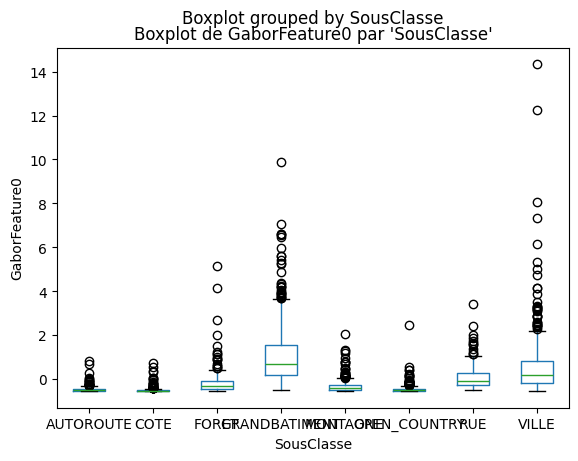

<Figure size 800x600 with 0 Axes>

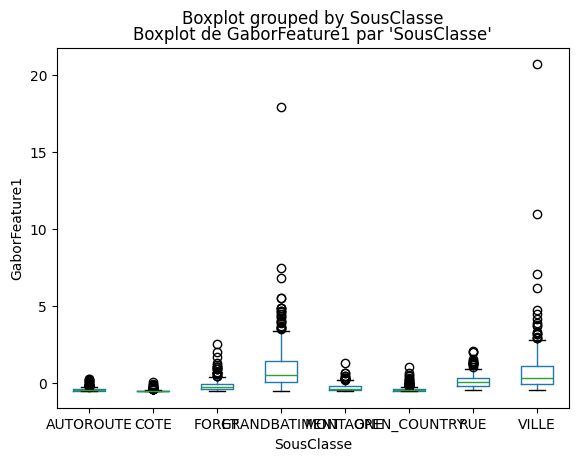

<Figure size 800x600 with 0 Axes>

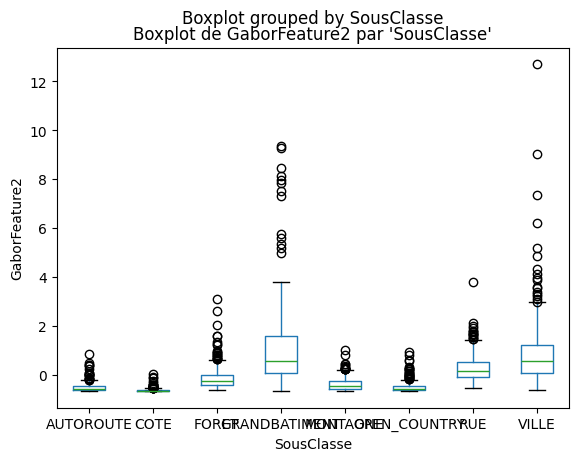

<Figure size 800x600 with 0 Axes>

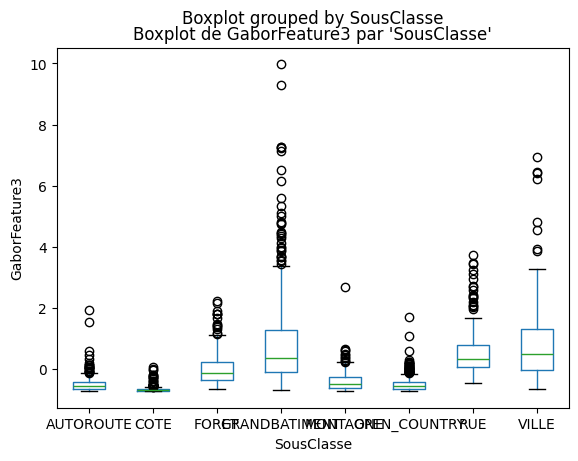

<Figure size 800x600 with 0 Axes>

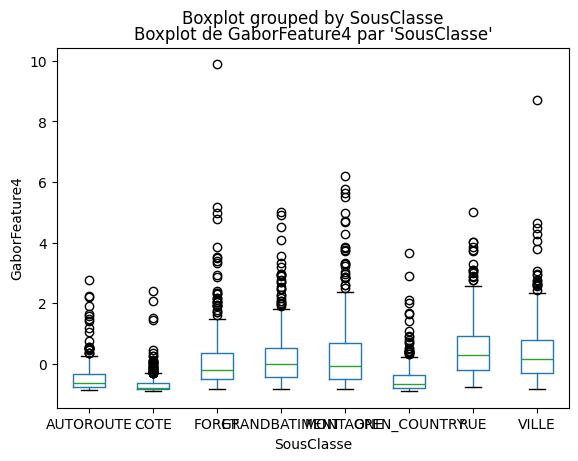

<Figure size 800x600 with 0 Axes>

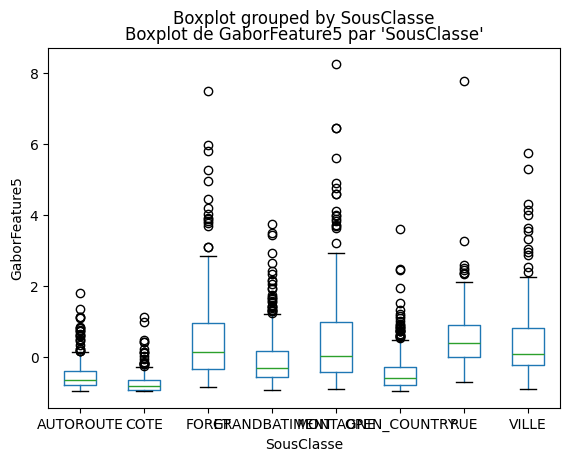

<Figure size 800x600 with 0 Axes>

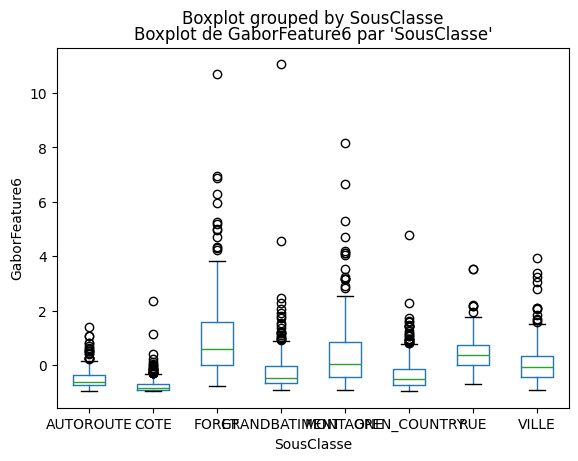

<Figure size 800x600 with 0 Axes>

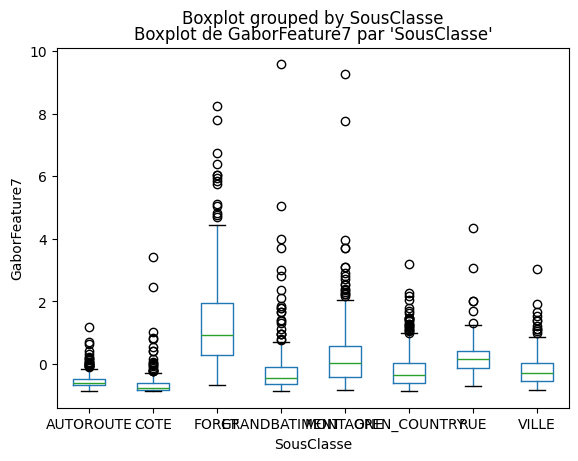

<Figure size 800x600 with 0 Axes>

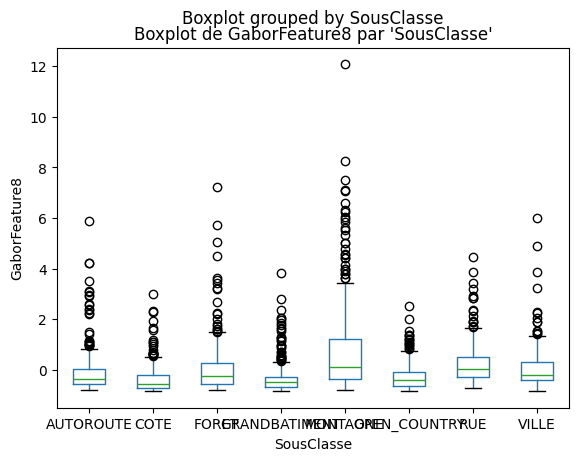

<Figure size 800x600 with 0 Axes>

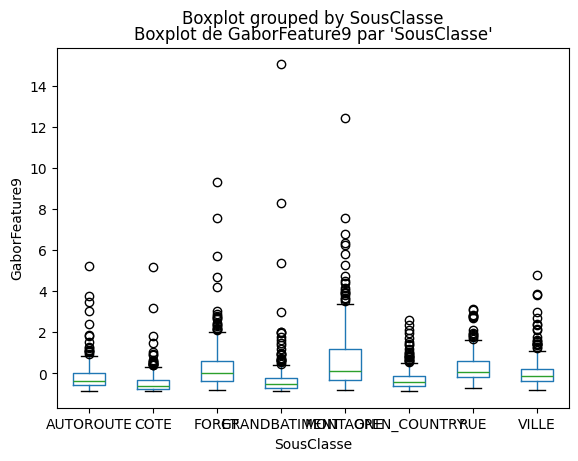

<Figure size 800x600 with 0 Axes>

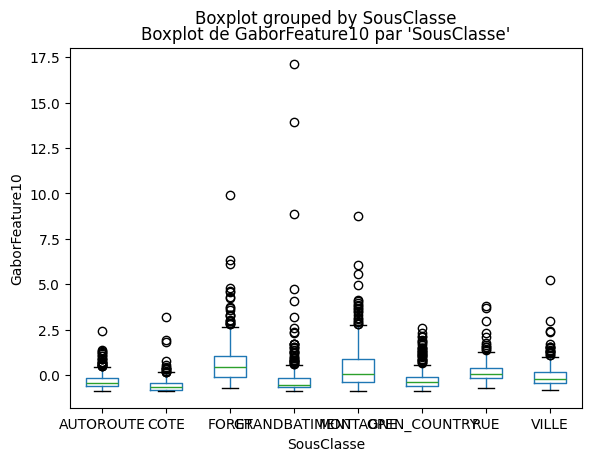

<Figure size 800x600 with 0 Axes>

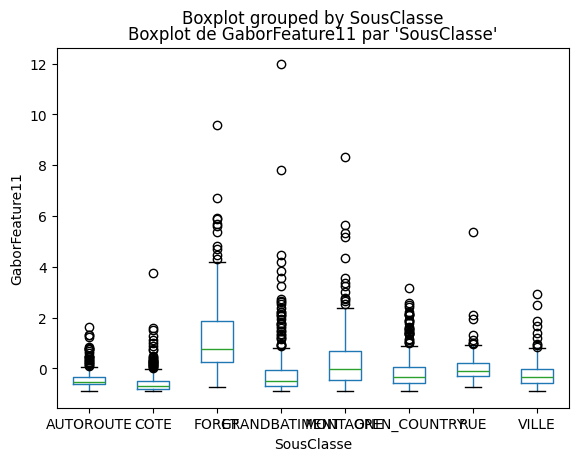

<Figure size 800x600 with 0 Axes>

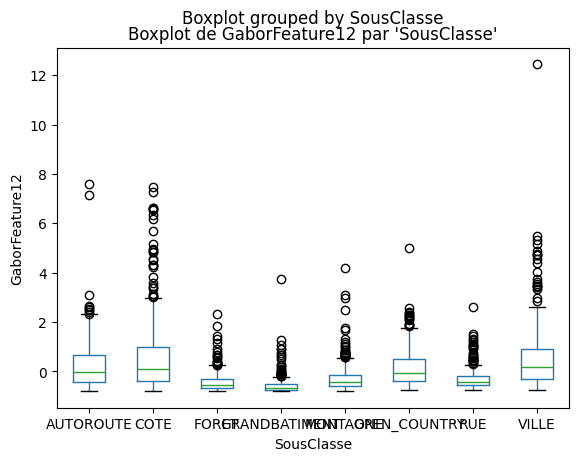

<Figure size 800x600 with 0 Axes>

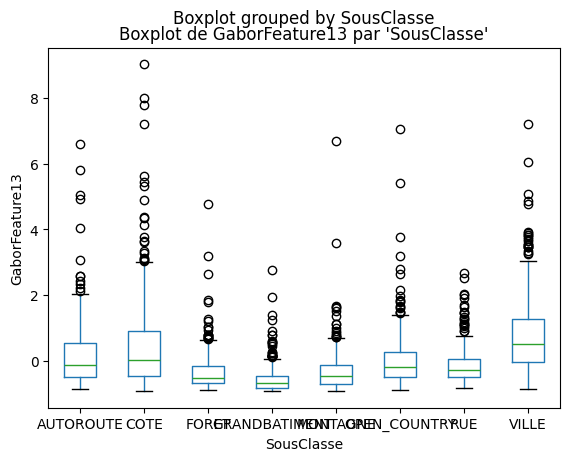

<Figure size 800x600 with 0 Axes>

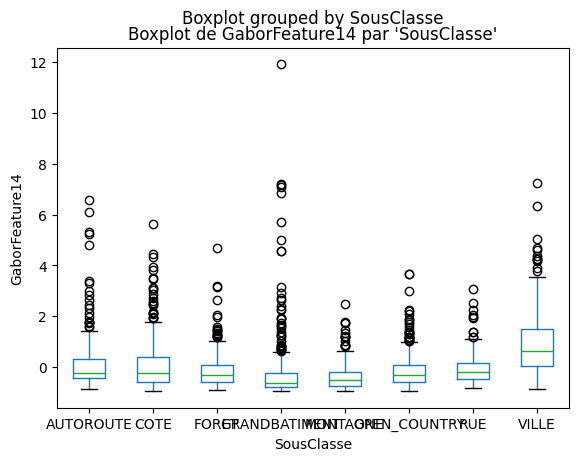

<Figure size 800x600 with 0 Axes>

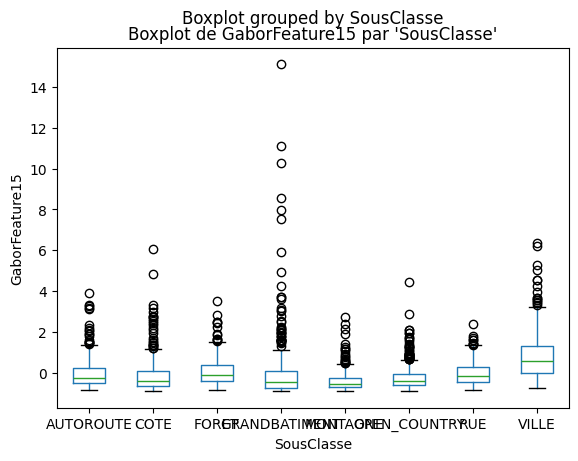

<Figure size 800x600 with 0 Axes>

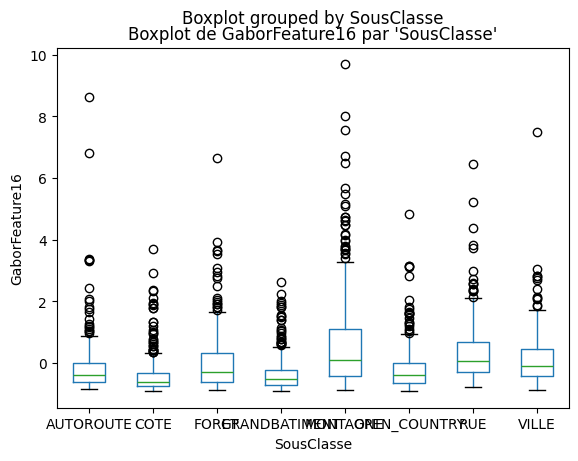

<Figure size 800x600 with 0 Axes>

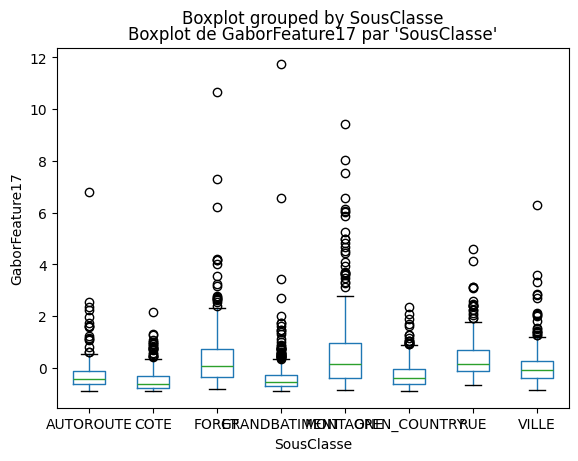

<Figure size 800x600 with 0 Axes>

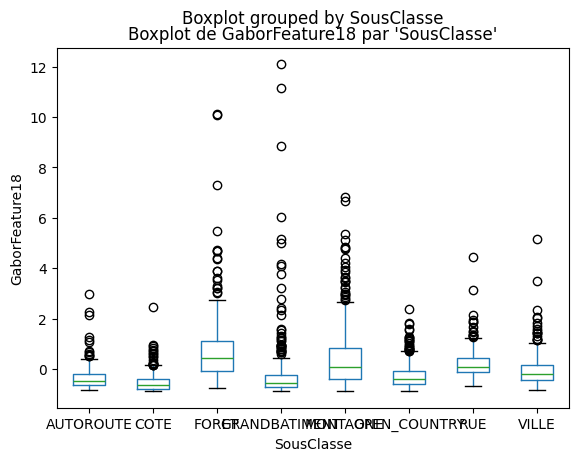

<Figure size 800x600 with 0 Axes>

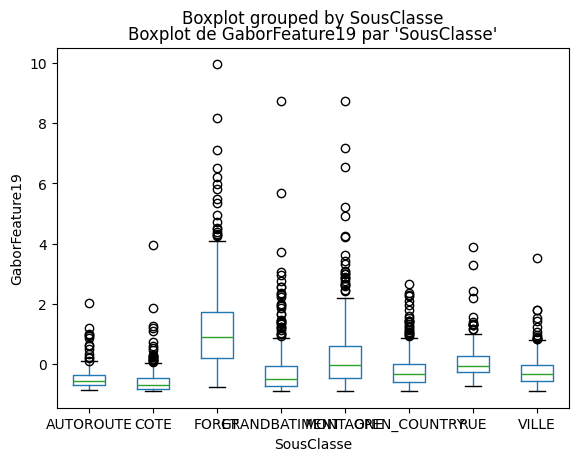

<Figure size 800x600 with 0 Axes>

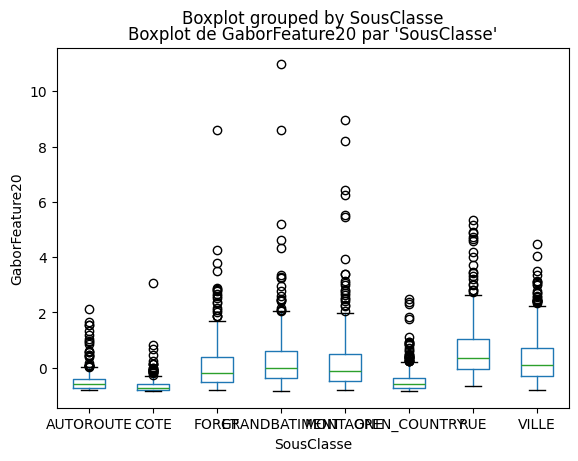

<Figure size 800x600 with 0 Axes>

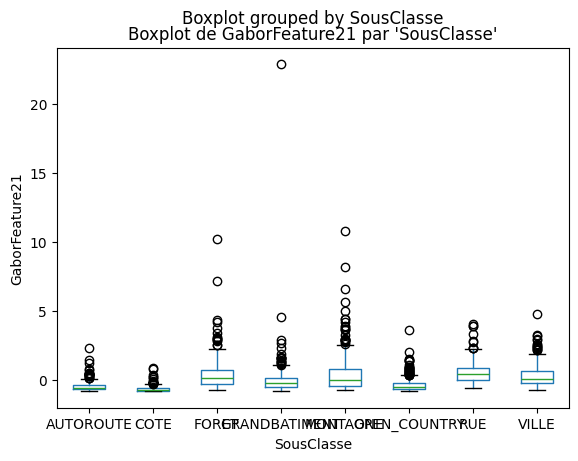

<Figure size 800x600 with 0 Axes>

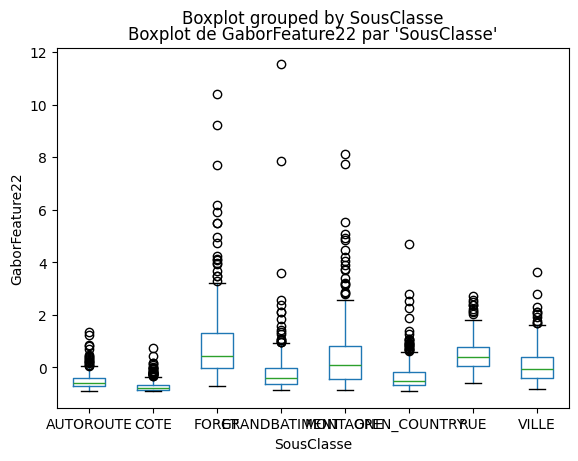

<Figure size 800x600 with 0 Axes>

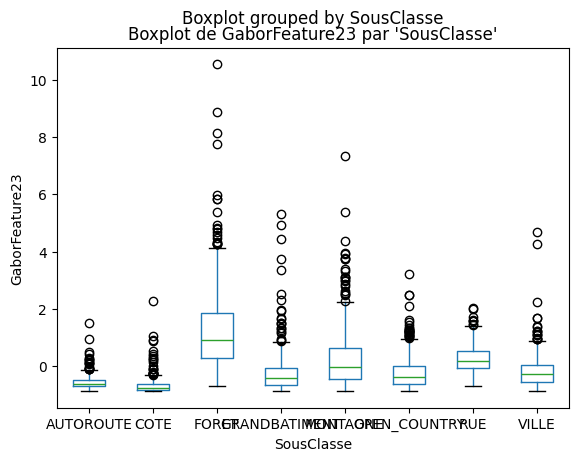

<Figure size 800x600 with 0 Axes>

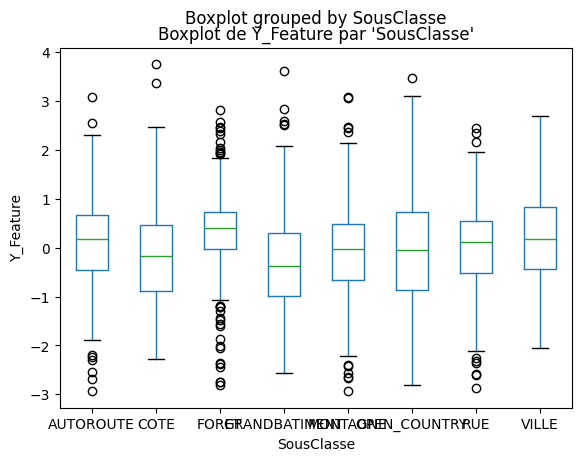

<Figure size 800x600 with 0 Axes>

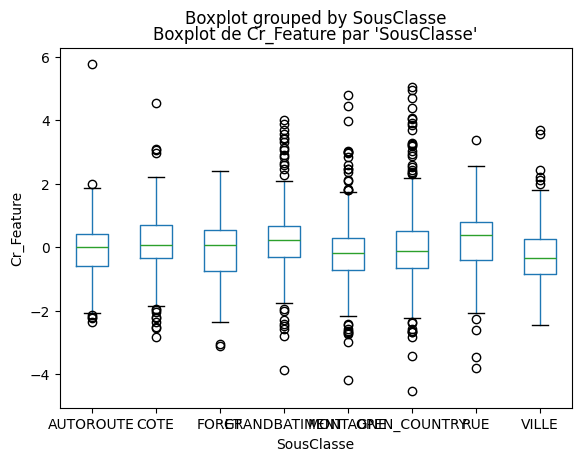

<Figure size 800x600 with 0 Axes>

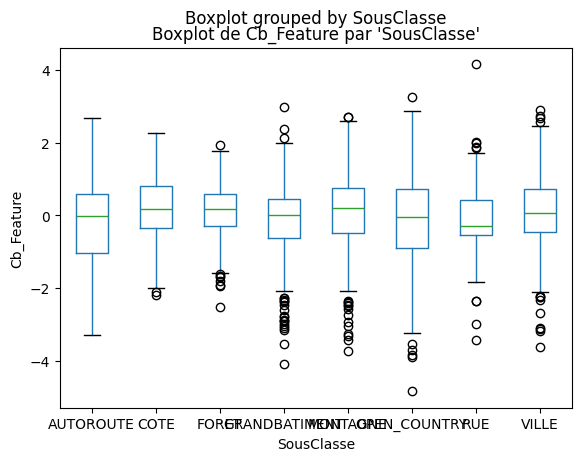

In [80]:
# Affichage des boxplots triés par 'Classe'
# On ne trace que les colonnes numériques pour éviter les erreurs (p.ex. la colonne 'Classe' est de type object)
numeric_cols = database.select_dtypes(include=[np.number]).columns.tolist()

# Optionnel : exclure la colonne 'Numero' si elle n'est pas pertinente
if 'Numero' in numeric_cols:
    numeric_cols.remove('Numero')

for column in numeric_cols:
    plt.figure(figsize=(8, 6))
    database.boxplot(column=column, by='SousClasse', grid=False)
    plt.title(f"Boxplot de {column} par 'SousClasse'")
    plt.xlabel('SousClasse')
    plt.ylabel(column)
    plt.show()

In [81]:
X1 = database.copy()
le = LabelEncoder()

# Encoder les classes en valeurs numériques
y_encoded = le.fit_transform(X1['SousClasse'])

# Sélectionner toutes les lignes (pas seulement [:2]) et les colonnes numériques
numeric_cols = X1.select_dtypes(include=[np.number]).columns.tolist()
if 'Numero' in numeric_cols:
    numeric_cols.remove('Numero')

"""
# Créer la matrice de dispersion
pd.plotting.scatter_matrix(X1[numeric_cols], c=y_encoded, figsize=(15, 15), alpha=0.8, cmap='viridis')
plt.suptitle('Matrice de dispersion colorée par SousClasse')
plt.show()
"""

"\n# Créer la matrice de dispersion\npd.plotting.scatter_matrix(X1[numeric_cols], c=y_encoded, figsize=(15, 15), alpha=0.8, cmap='viridis')\nplt.suptitle('Matrice de dispersion colorée par SousClasse')\nplt.show()\n"

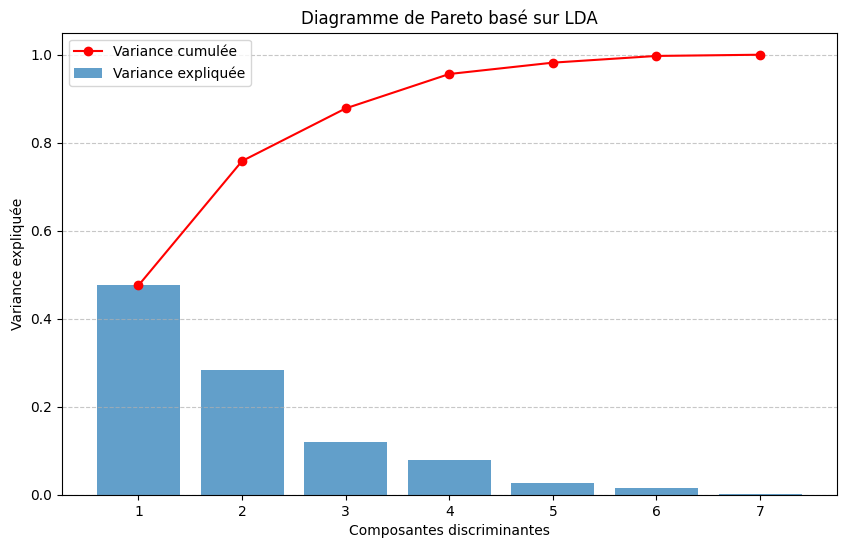

In [82]:

############  ALD ###########


lda = LinearDiscriminantAnalysis() 

# Sélectionner uniquement les colonnes numériques (exclure 'Classe', 'SousClasse', 'Numero')
X1_num = X1.select_dtypes(include=[np.number]).columns.tolist()
if 'Numero' in X1_num:
    X1_num.remove('Numero')

# Appliquer LDA
coord_lda = lda.fit_transform(X1[X1_num], y_encoded)

# Calculer la variance expliquée par chaque composante discriminante
explained_variance_ratio = lda.explained_variance_ratio_

# Créer un diagramme de Pareto
sorted_indices = np.argsort(explained_variance_ratio)[::-1]
sorted_variance = explained_variance_ratio[sorted_indices]
cumulative_variance = np.cumsum(sorted_variance)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(sorted_variance) + 1), sorted_variance, alpha=0.7, label='Variance expliquée')
plt.plot(range(1, len(sorted_variance) + 1), cumulative_variance, marker='o', color='r', label='Variance cumulée')

plt.xlabel('Composantes discriminantes')
plt.ylabel('Variance expliquée')
plt.title('Diagramme de Pareto basé sur LDA')
plt.xticks(range(1, len(sorted_variance) + 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

avec deux variables on n'aurait que 70% de précision, donc on a besoin de plus
au moins 5 ou 6 composantes discriminantes au minimum

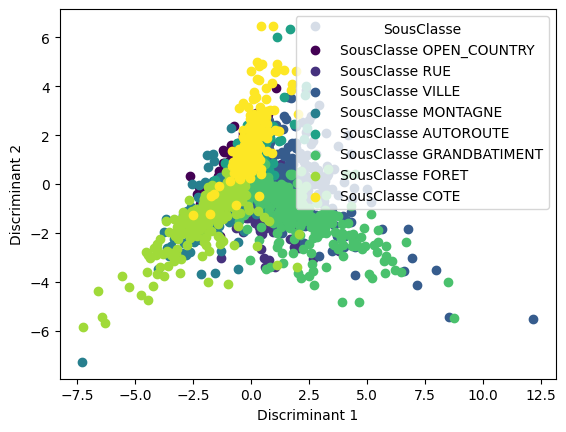

In [83]:
plt.figure()

# Création d'une palette de couleurs, juste esthétique
unique_codes = X1['SousClasse'].unique()
colors = cm.viridis(np.linspace(0, 1, len(unique_codes)))  # Génère des couleurs distinctes
color_map = dict(zip(unique_codes, colors))  # Associe chaque code à une couleur

# Tracé des points avec les couleurs correspondantes
for SousClasse in unique_codes:
    mask = X1['SousClasse'] == SousClasse
    plt.scatter(coord_lda[mask, 0], coord_lda[mask, 1], color=color_map[SousClasse], label=f'SousClasse {SousClasse}')     #on sélectionne les composantes discriminantes 1 et 2

# Ajout des étiquettes et de la légende
plt.xlabel('Discriminant 1')
plt.ylabel('Discriminant 2')
plt.legend(title='SousClasse')
plt.show()

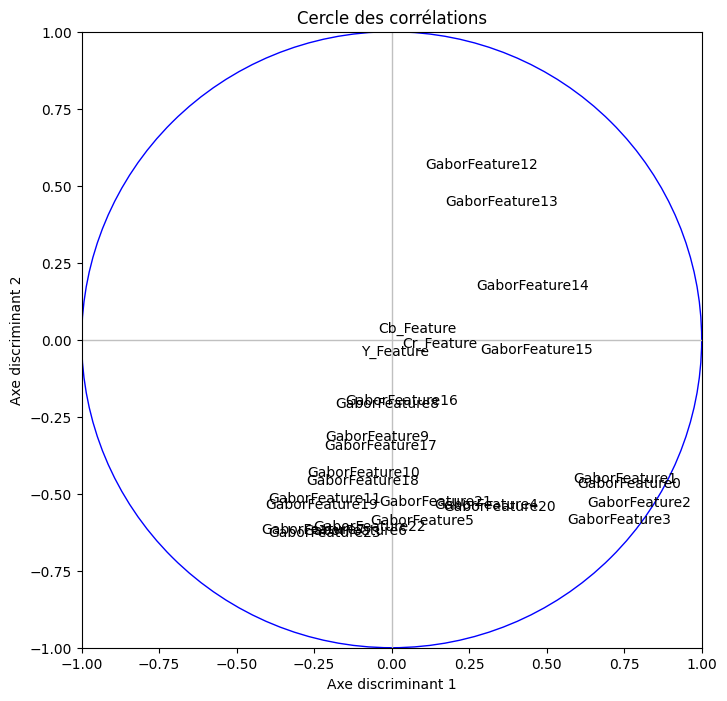

In [84]:
# Cercle des corrélations
fig, axes = plt.subplots(figsize=(8, 8))
axes.set_xlim(-1, 1)
axes.set_ylim(-1, 1)

# Calcul des corrélations entre les variables et les axes discriminants
# On utilise uniquement les features numériques (celles utilisées dans LDA)
for i, feature in enumerate(X1_num):
    # Calcul des coordonnées des variables sur le cercle
    x_corr = np.corrcoef(X1[feature], coord_lda[:, 0])[0, 1]
    y_corr = np.corrcoef(X1[feature], coord_lda[:, 1])[0, 1]
    
    # Affichage des noms des variables
    plt.annotate(feature, (x_corr, y_corr))

# Ajout des axes
plt.plot([-1, 1], [0, 0], color='silver', linestyle='-', linewidth=1)
plt.plot([0, 0], [-1, 1], color='silver', linestyle='-', linewidth=1)

# Ajout du cercle
cercle = plt.Circle((0, 0), 1, color='blue', fill=False)
axes.add_artist(cercle)

# Titres et affichage
plt.title("Cercle des corrélations")
plt.xlabel("Axe discriminant 1")
plt.ylabel("Axe discriminant 2")
plt.grid(False)
plt.show()

In [85]:
# Séparation train/test
X_training = X1_num.iloc[:420, :-1]         #les 420 premières lignes pour l'entraînement
y_training = X1_num.iloc[:420, -1]          #Y contient juste la variable à prédire, ici la phase
X_test = X1_num.iloc[420:, :-1]             #le reste pour le test
y_test = X1_num.iloc[420:, -1]

# Entraînement du modèle LDA
lda = LinearDiscriminantAnalysis()
lda.fit_transform(X_training, y_training)

# Prédiction sur les données de test
y_test_pred = lda.predict(X_test)

# Matrice de confusion
confusion = confusion_matrix(y_test, y_test_pred)
confusion_pct = confusion.astype('float') / confusion.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8, 6))
sb.heatmap(confusion_pct, annot=True, fmt='.2f', cmap='Blues')
plt.title('Matrice de confusion - LDA')
plt.xlabel('Prédit')
plt.ylabel('Véritable')
plt.show()

print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.3f}")

AttributeError: 'list' object has no attribute 'iloc'

In [ ]:
# Partie 1.2
utils.show_database(database,1,2) # pour verifier les bases et afficher un exemple images


#Base_im,label1,label2,Caract=utils.lire_images_et_carac("./images",'./database.csv',2688,sous_ech=2)

# with open('data.tout_128', 'wb') as f:
#     pickle.dump([Base_im,label1,label2,Caract],f)

# # Pour charger toutes les données de la base "à la matlab" comme un load
# # Ca suppose que le fichier data.pickle a déjà été fait
 
with open('data.tout_128', 'rb') as f:
    Base_im, label1, label2,caract = pickle.load(f)

Base_im=np.array(Base_im)   
caract=np.array(caract) 
    
Base_im=(Base_im/255)-0.5


Base_tot=list(zip(Base_im, caract))

datatrain, datatest, datalabeltrain, datalabeltest = train_test_split(Base_tot, label2-2, test_size=0.2, random_state=None)

imtrain,caractrain=zip(*datatrain)
imtest,caractest=zip(*datatest)


mc=[]
titre=[]
report=[]
resu_acc=[]
resu_acc_class=[]
int_conf=[]




I=datatrain[0][0]
(img_width, img_height, nb_plan)=np.shape(I)

#vérification pour que les entrées du réseau soient correctes
if K.image_data_format() == 'channels_first': 
    input_shape = (3, img_width, img_height) 
else: 
    input_shape = (img_width, img_height, 3) 
    
imdata=[]
imdata2=[]
for i in np.arange(len(datalabeltrain)):
    imdata.append(datatrain[i][0])
for i in np.arange(len(datalabeltest)):   
    imdata2.append(datatest[i][0])
imdatatrain=np.array(imdata)
imdatatest=np.array(imdata2)



#############################################################################################################
# Le transfert learning
#############################################################################################################

###################################################################################################################################
# CNN definition transfert learning
# load model without classifier layers
    
base_model= VGG16(include_top=False, input_shape=input_shape) #choisir la taille qui correspond à la taille des images étudiées
#base_model = InceptionV3(weights='imagenet', include_top=False)

# add a global spatial average pooling layer
x = base_model.output
x=Flatten()(x) #pour VGG16
#x = GlobalAveragePooling2D()(x) # A la place de Flatten()
# let's add a fully-connected layer
x = Dense(500, activation='relu')(x)
x = Dropout(0.2)(x)
#x = Dense(20, activation='relu')(x)
# and a logistic layer -- On a 8 classes en sortie
predictions = Dense(8, activation='softmax')(x)


# this is the model we will train
model = Model(inputs=base_model.input, outputs=predictions)

#####################################################################################################################
#Etape de fine-Tuning

#Pour inception
#Nbr_couches_gelees=249

#Pour VGG16
Nbr_couches_gelees=18
#####################################################################################################################

for layer in model.layers[:Nbr_couches_gelees]:
    layer.trainable = False
for layer in model.layers[Nbr_couches_gelees:]:
    layer.trainable = True

# on recompile le nouveau modèle
#model.compile(optimizer='rmsprop', loss='categorical_crossentropy',metrics=['accuracy'])
model.compile(optimizer='sgd', loss='categorical_crossentropy',metrics=['accuracy'])
n_epochs=3
  #nombre epoch pour le fine-tuning 
 

H=model.fit(
            imdatatrain, to_categorical(datalabeltrain),
            epochs=n_epochs,
            validation_split=0.3, verbose=1) #ici verbose = 2 
    #pour pouvoir ressortir les informations de loss et d'accuracy 
    #dans une variable obtenue avec la methode history : H.history
print(H.history)



N = np.arange(0, n_epochs)
plt.figure()
plt.plot(N, H.history["loss"], label="train_loss")
plt.plot(N, H.history["val_loss"], label="val_loss")
plt.legend(loc="lower left")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.title("Training Loss on Dataset")
  

labels_predit = model.predict(imdatatest)


mc.append(confusion_matrix(datalabeltest,np.argmax(labels_predit,axis=1)))


acc=balanced_accuracy_score(datalabeltest, np.argmax(labels_predit,axis=1))
resu_acc.append(acc)
titre.append(f'Transfert avec Inception, accuracy={acc:.2f}]')
resu=classification_report(datalabeltest,np.argmax(labels_predit,axis=1),target_names=['2','3','4','5','6','7','8','9'],output_dict=True)
report.append(classification_report(datalabeltest,np.argmax(labels_predit,axis=1),target_names=['2','3','4','5','6','7','8','9'],output_dict=True))

acc_class=np.arange(8)*0.0
for i in np.arange(0,8):
    acc_class[i]=np.around(resu[str(i+2)]['precision'],3)
resu_acc_class.append(acc_class)


Contenu Total: 2688
Classée Artificielle: 1216
Classée Naturelle: 1472
Classée Côte: 360
Classée Forêt: 328
Classée Autoroute: 260
Classée Ville: 308
Classée Montagne: 374
Classée Paysage Ouvert: 410
Classée Rue: 292
Classée Grand Batiment: 356
 


FileNotFoundError: [Errno 2] No such file or directory: 'data.tout_128'